# Chapter 8 (Economic Modeling) — IIASA SSP Database Pathways

Port of `chap8_iam_ssp3.m` through `chap8_iam_ssp8.m` — the sixth Chapter
8 Part 2 notebook, and the largest single collapse decision in Part 2.
The 16 single-panel `iam_ssp4a-d`/`5a-d`/`6a-d`/`7a-d` scripts are each
*exactly* one panel of the corresponding grouped 2x2 figure (`ssp4`,
`5`, `6`, `7`) — confirmed line-by-line: identical data-loading and
plotting code, differing only in which named struct is loaded. They are
covered by the 6 grouped sections below (via one shared plotting helper)
rather than rebuilt as 16 near-duplicate standalone figures.

**A data-format note, more involved than the usual MCOS string-array
gap elsewhere in Part 2:** every one of the 24 named structs in
`chap8_iamc_db_ssp.mat` carries a `scenario` field needed to sort its 5
columns into SSP1$\to$SSP5 legend order (`[~,orders]=sort(scenario)` in
every source script) — and that field is MCOS-unreadable, same as
elsewhere. What's different here is that the *raw column order itself
varies by variable*: the two providers behind this database use
different row conventions. The OECD Env-Growth-sourced variables (`GDP`,
`Population`, `GDP_per_Capita`, `Growth`, `Urban`) store their 5 columns
already in SSP1$\to$SSP5 order; every other (IIASA multi-model-sourced)
variable stores them in model order (AIM/CGE$\to$SSP3, GCAM4$\to$SSP4,
IMAGE$\to$SSP1, MESSAGE-GLOBIOM$\to$SSP2, REMIND-MAGPIE$\to$SSP5),
confirmed directly against the `.xlsx` sibling's `Scenario` column for
every sheet used here. Rather than hardcode this split, the notebook
reconstructs each sheet's actual `orders` permutation at runtime by
reading that column from the `.xlsx` sibling and reproducing MATLAB's
`extractBetween(scenario,1,4)` + `sort()` exactly — the same technique
as the string-array workarounds used throughout Part 2, applied here
per-sheet rather than once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.interpolate import PchipInterpolator
from scipy.io.matlab import MatReadWarning

warnings.filterwarnings("ignore", category=MatReadWarning)

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

color_green = "#2ca02c"
color_teal = "#008080"
color_blue = "#1f77b4"
color_orange = "#ff7f0e"
color_red = "#d62728"
color_black = "#000000"

SSP_COLORS = [color_green, color_teal, color_blue, color_orange, color_red]
SSP_LABELS = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]
SSP_STYLES = ["-", "--", ":", "-", "--"]
SSP_WIDTHS = [1.75, 1.75, 2.00, 1.75, 1.75]

d_ssp = sio.loadmat(f"{DATA_DIR}/chap8_iamc_db_ssp.mat")
_xlsx_path = f"{DATA_DIR}/chap8_iamc_db_ssp.xlsx"

_sheet_order_cache = {}

def get_sheet_order(varname):
    if varname not in _sheet_order_cache:
        df = pd.read_excel(_xlsx_path, sheet_name=varname, header=None)
        scen_raw = df.iloc[1:6, 1].astype(str).tolist()
        scen4 = [s[:4] for s in scen_raw]  # extractBetween(scenario,1,4)
        _sheet_order_cache[varname] = list(np.argsort(scen4, kind="stable"))
    return _sheet_order_cache[varname]

def plot_ssp_panel(ax, varname, scale, title, ylim, xlim=(2010, 2100),
                    scale_first_observation=False, x_step=1, legend=False):
    buf = d_ssp[varname][0, 0]
    dates = buf["dates"].ravel().astype(float)
    data = buf["data"] / scale
    orders = get_sheet_order(varname)

    if scale_first_observation:
        m = data[0, :].mean()
        data = data / data[0, :] * m

    x = np.arange(dates[0], 2100 + x_step / 2, x_step)
    for i in range(5):
        col = data[:, orders[i]]
        mask = ~np.isnan(col)  # a few sheets (Growth, Growth_Africa, Growth_Asia) carry a
        # trailing NaN row (date=2100, all 5 columns at once) -- drop it per-column before
        # interpolating, consistent with the pchip_eval/_packr_pchip NaN-masking pattern
        # used elsewhere in Part 2 (08j, 08l).
        y = PchipInterpolator(dates[mask], col[mask])(x)
        ax.plot(x, y, SSP_STYLES[i], color=SSP_COLORS[i], lw=SSP_WIDTHS[i],
                label=SSP_LABELS[i])
    if title:
        ax.set_title(title, fontsize=11)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    if legend:
        ax.legend(fontsize=9)
    return dates, data, orders


## Question 1 (`iam_ssp3`) — Population

Single-panel figure, plotted from the data's own first observed date
(1960s) rather than a fixed 2010 start, since it's the one panel in this
family meant to show historical population alongside the SSP
projections.

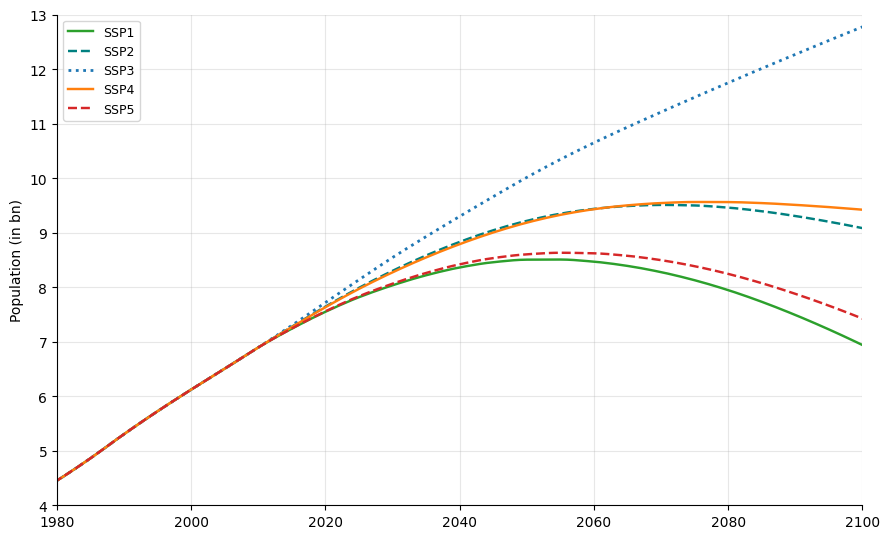

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_ssp_panel(ax, "Population", 1e3, None, (4, 13), xlim=(1980, 2100), legend=True)
ax.set_ylabel("Population (in bn)")
plt.tight_layout()
plt.show()


## Question 2 (`iam_ssp4`) — GDP family (covers `ssp4a-d`)

2x2 panel: GDP, GDP per capita, GDP growth (rescaled so all 5 scenarios
share the same first-year value — the source's `scale_first_observation`
step, since the underlying models don't perfectly agree on the 2010
starting growth rate even though they should represent the same
observed history), and GDP per unit of primary energy (same rescaling).

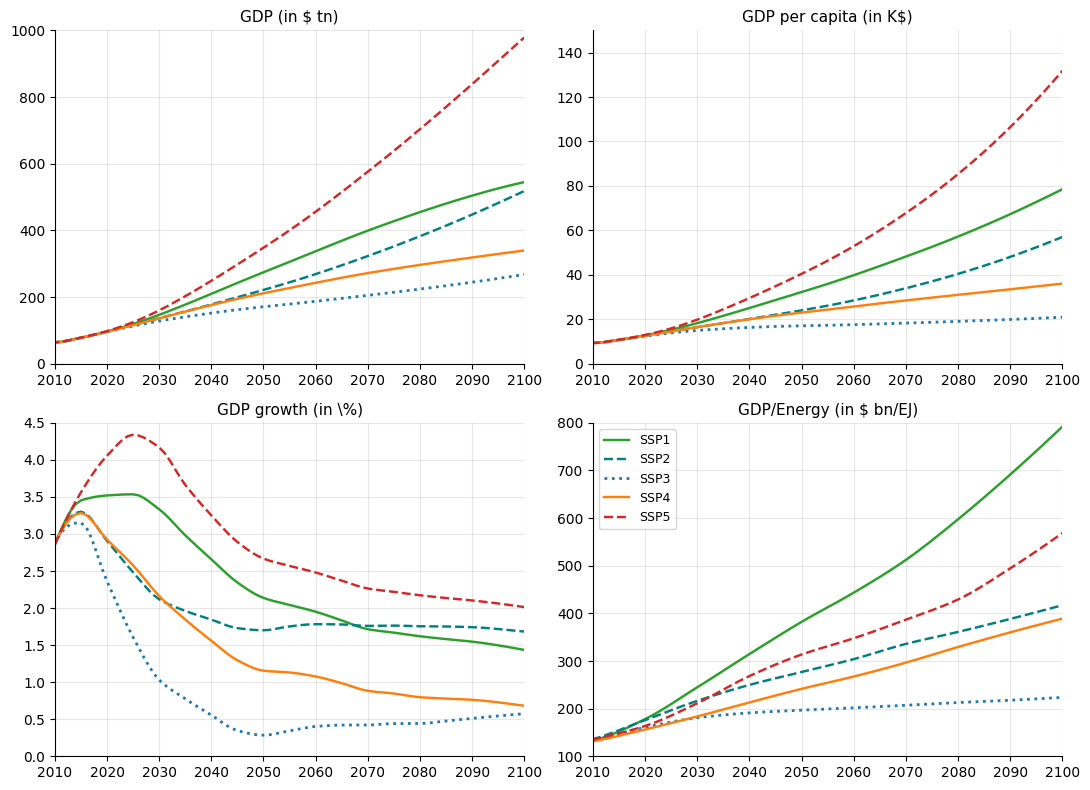

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_ssp_panel(axes[0, 0], "GDP", 1e3, "GDP (in \\$ tn)", (0, 1000))
plot_ssp_panel(axes[0, 1], "GDP_per_Capita", 1, "GDP per capita (in K\\$)", (0, 150))
plot_ssp_panel(axes[1, 0], "Growth", 1, "GDP growth (in \\%)", (0, 4.5), scale_first_observation=True)
plot_ssp_panel(axes[1, 1], "GDP_per_Primary", 1, "GDP/Energy (in \\$ bn/EJ)", (100, 800),
               scale_first_observation=True, legend=True)
plt.tight_layout()
plt.show()


## Question 3 (`iam_ssp5`) — Climate/energy family (covers `ssp5a-d`)

2x2 panel: temperature, CO2 emissions (rescaled to a common first-year
value), solar and wind electricity capacity, all plotted from 2000.

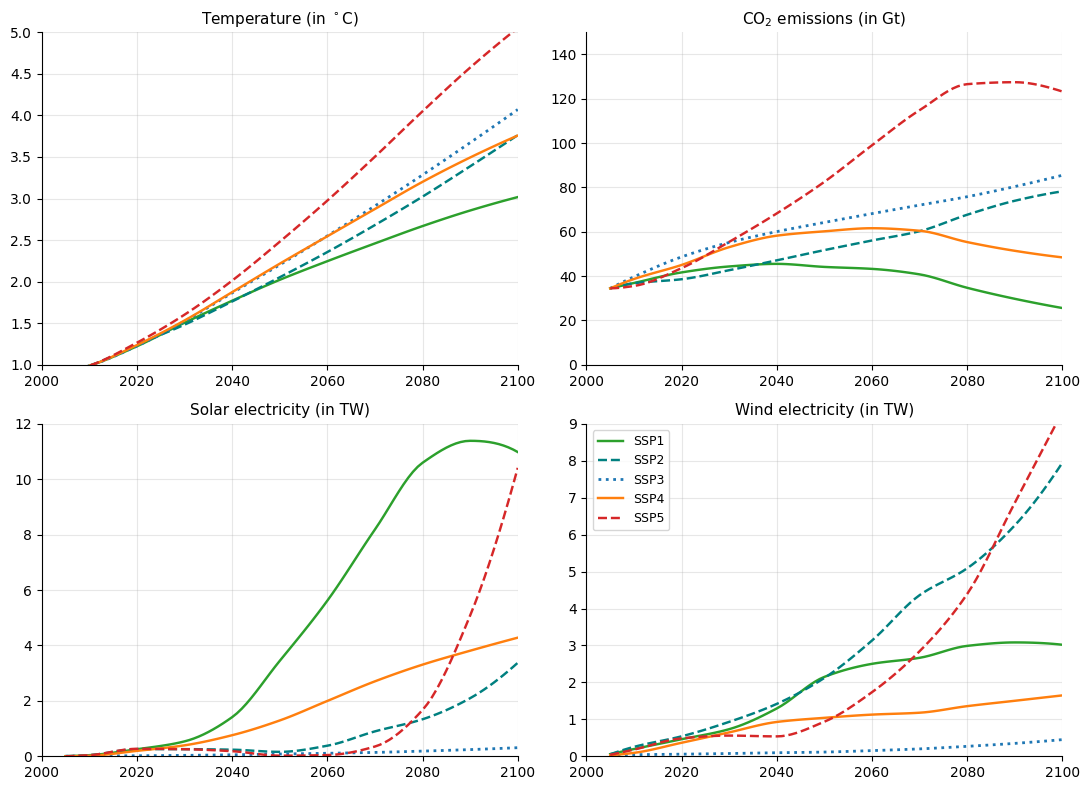

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_ssp_panel(axes[0, 0], "Temperature", 1, "Temperature (in $^\\circ$C)", (1, 5), xlim=(2000, 2100))
plot_ssp_panel(axes[0, 1], "CO2", 1000, "CO$_2$ emissions (in Gt)", (0, 150), xlim=(2000, 2100),
               scale_first_observation=True)
plot_ssp_panel(axes[1, 0], "Solar", 1000, "Solar electricity (in TW)", (0, 12), xlim=(2000, 2100))
plot_ssp_panel(axes[1, 1], "Wind", 1000, "Wind electricity (in TW)", (0, 9), xlim=(2000, 2100), legend=True)
plt.tight_layout()
plt.show()


## Question 4 (`iam_ssp6`) — Land-use family (covers `ssp6a-d`)

2x2 panel: urban population share, forest, cropland, and pasture area
(the latter three rescaled to a common first-year value), all plotted
from 2000.

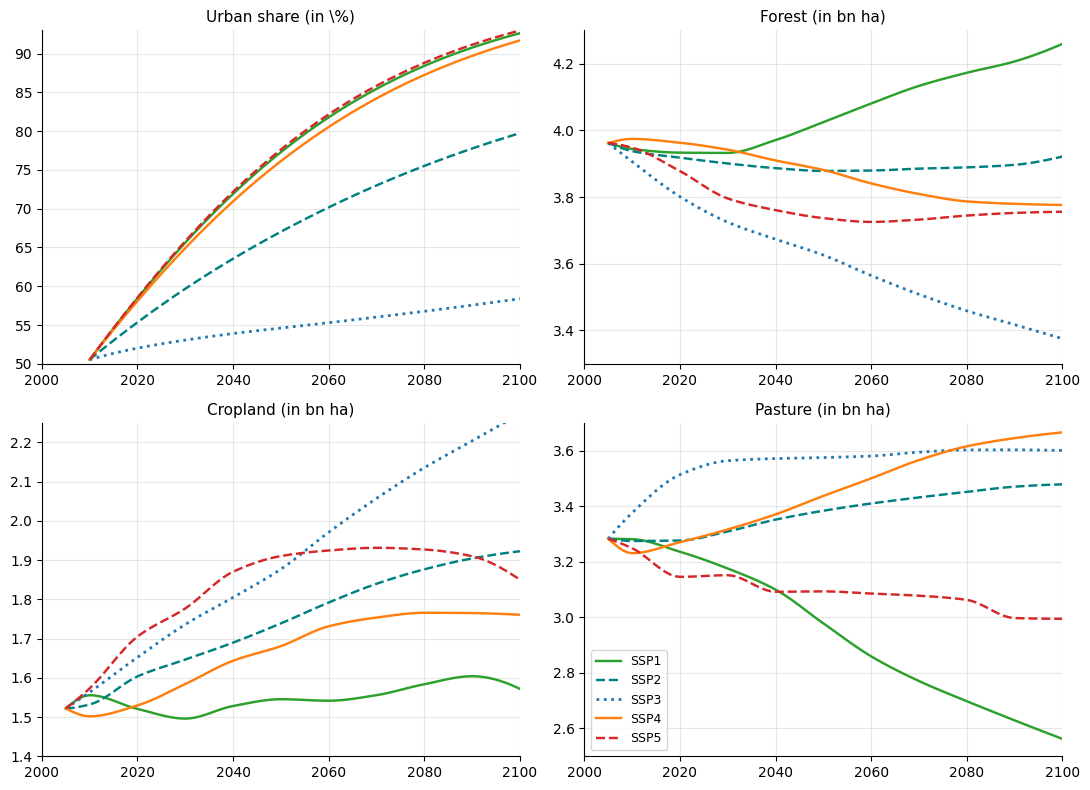

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_ssp_panel(axes[0, 0], "Urban", 1, "Urban share (in \\%)", (50, 93), xlim=(2000, 2100))
plot_ssp_panel(axes[0, 1], "Forest", 1000, "Forest (in bn ha)", (3.3, 4.30), xlim=(2000, 2100),
               scale_first_observation=True)
plot_ssp_panel(axes[1, 0], "Cropland", 1000, "Cropland (in bn ha)", (1.40, 2.25), xlim=(2000, 2100),
               scale_first_observation=True)
plot_ssp_panel(axes[1, 1], "Pasture", 1000, "Pasture (in bn ha)", (2.5, 3.7), xlim=(2000, 2100),
               scale_first_observation=True, legend=True)
plt.tight_layout()
plt.show()


## Question 5 (`iam_ssp7`) — Regional population/growth family (covers `ssp7a-d`)

2x2 panel: Africa and Asia population, Africa and Asia GDP/capita
growth (all rescaled to a common first-year value), all plotted from
2000. **A coverage note, not a bug:** the `vars` list declared at the
top of every script in this family also names `Population_OECD`,
`Population_Latam`, `Growth_OECD`, and `Growth_Latam` — but no script
anywhere in the archive (grouped or single-panel) actually plots them;
only the Africa/Asia pair appears. The data exists in
`chap8_iamc_db_ssp.mat` (loadable the same way) but is unused by the
source itself, not by an omission on the Python side.

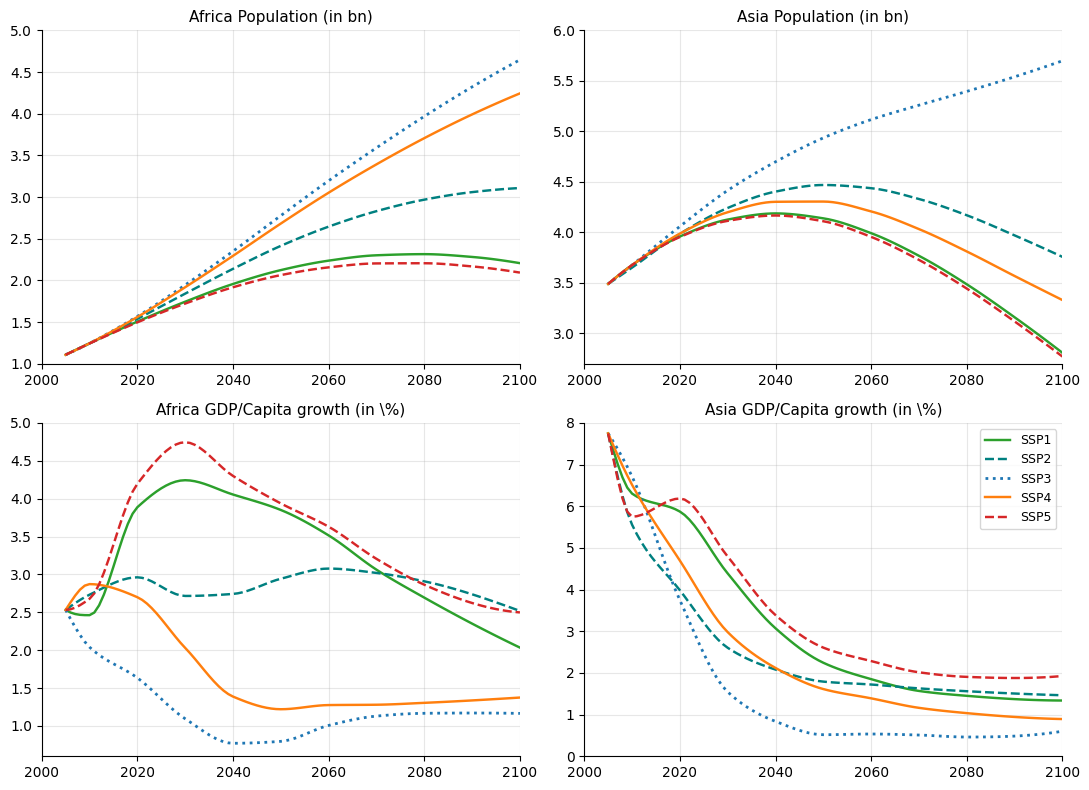

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_ssp_panel(axes[0, 0], "Population_Africa", 1000, "Africa Population (in bn)", (1, 5), xlim=(2000, 2100),
               scale_first_observation=True)
plot_ssp_panel(axes[0, 1], "Population_Asia", 1000, "Asia Population (in bn)", (2.7, 6), xlim=(2000, 2100),
               scale_first_observation=True)
plot_ssp_panel(axes[1, 0], "Growth_Africa", 1, "Africa GDP/Capita growth (in \\%)", (0.6, 5), xlim=(2000, 2100),
               scale_first_observation=True)
plot_ssp_panel(axes[1, 1], "Growth_Asia", 1, "Asia GDP/Capita growth (in \\%)", (0, 8), xlim=(2000, 2100),
               scale_first_observation=True, legend=True)
plt.tight_layout()
plt.show()


## Question 6 (`iam_ssp8`) — Terminal Gini-coefficient boxplot

`chap8_iamc_db_ssp_gini.mat`'s `Gini` array (184 countries $\times$ 5
SSPs $\times$ 10 dates). The 2020 cross-SSP mean is shown as a single
reference box, followed by each SSP's full 2100 distribution.
**A quirk reproduced faithfully:** the source inserts a second box
between the 2020 reference and the SSP1-5 boxes using `-data1` (the
*negated* 2020 values) purely to create visual spacing — since MATLAB's
`boxplot` has no direct "empty slot" option, a box plotted far outside
the visible y-range ($[10,80]$) achieves the same effect. Reproduced
below (it renders as an empty gap in the visible range, exactly as
intended) rather than dropped.

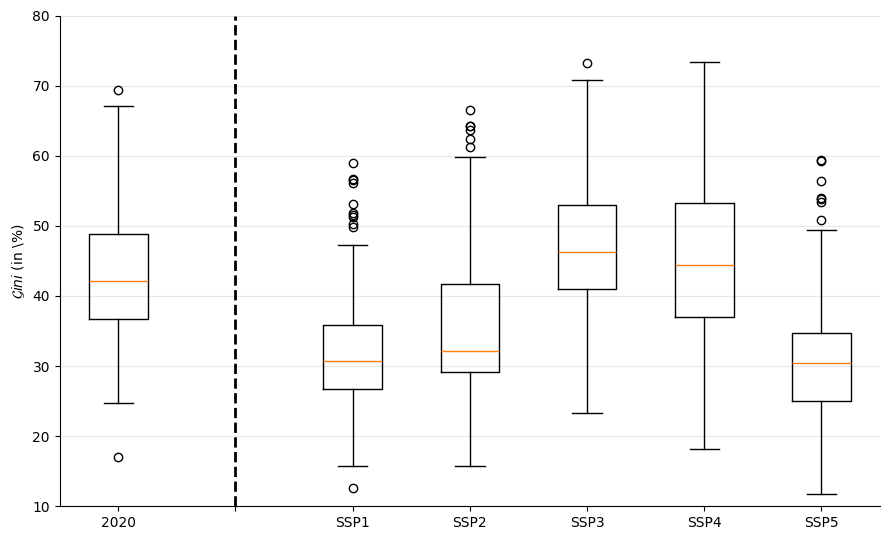

In [7]:
d_gini = sio.loadmat(f"{DATA_DIR}/chap8_iamc_db_ssp_gini.mat")
gini = d_gini["Gini"]
dates_gini = d_gini["dates"].ravel()

idx_2020 = np.where(dates_gini == 2020)[0][0]
idx_2100 = np.where(dates_gini == 2100)[0][0]

data1 = gini[:, :, idx_2020].mean(axis=1)  # (184,) -- mean across SSPs at 2020
data2 = gini[:, :, idx_2100]  # (184, 5) -- full 2100 distribution per SSP

box_data = [data1, -data1] + [data2[:, i] for i in range(5)]
box_labels = ["2020", " ", "SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(box_data, tick_labels=box_labels)
ax.axvline(2, linestyle="--", color=color_black, lw=2.0)
ax.set_ylabel("$\\mathcal{G}ini$ (in \\%)")
ax.set_ylim(10, 80)
ax.grid(True, which="both", axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Sanity checks

In [8]:
checks = []
_pop_dates = d_ssp['Population'][0,0]['dates'].ravel().astype(float)
_pop_orders = get_sheet_order('Population')
_pop_raw = [d_ssp['Population'][0,0]['data'][:, _pop_orders[i]] / 1e3 for i in range(5)]
checks.append(("Q1: SSP3 (the \"regional rivalry\" scenario) is the only SSP whose raw "
                "quinquennial population series is monotonically non-decreasing all the way "
                "to 2100 -- SSP1/2/4/5 each peak mid-century and decline thereafter, a real, "
                "well-known SSP divergence in population projections rather than a data or "
                "interpolation bug (an earlier version of this check wrongly assumed all 5 "
                "scenarios grow monotonically through 2100)",
                np.all(np.diff(_pop_raw[2]) >= -1e-9) and
                all(np.any(np.diff(_pop_raw[i]) < -1e-9) for i in [0, 1, 3, 4])))
checks.append(("Q1: the interpolated (pchip, yearly grid 1980-2100) population curve stays "
                "positive throughout for every SSP scenario",
                all(np.all(PchipInterpolator(_pop_dates, _pop_raw[i])(np.arange(1980, 2101)) > 0)
                    for i in range(5))))
checks.append(("Q2-5: every reconstructed sheet order is a valid permutation of [0..4] "
                "(argsort of 5 distinct scenario codes)",
                all(sorted(get_sheet_order(v)) == [0, 1, 2, 3, 4] for v in
                    ["GDP", "Population", "GDP_per_Capita", "Growth", "Urban",
                     "Solar", "Wind", "Forest", "Cropland", "Pasture", "Temperature",
                     "Population_Africa", "Population_Asia", "Growth_Africa", "Growth_Asia",
                     "CO2", "GDP_per_Primary"])))
checks.append(("Q2-5: the OECD Env-Growth family (GDP, Population, GDP_per_Capita, Growth, "
                "Urban) is confirmed already in SSP1->SSP5 order (identity permutation), "
                "while every IIASA multi-model variable checked is confirmed in "
                "AIM/GCAM4/IMAGE/MESSAGE/REMIND model order (permutation [2,3,0,1,4])",
                get_sheet_order("GDP") == [0, 1, 2, 3, 4] and
                get_sheet_order("Temperature") == [2, 3, 0, 1, 4] and
                get_sheet_order("CO2") == [2, 3, 0, 1, 4]))
checks.append(("Q6: the 2020 reference box (data1) and its negated spacer (-data1) are exact "
                "mirror images of each other, by construction -- sorted ascending, one is the "
                "reverse of the other's negation (an earlier version of this check compared "
                "np.sort(data1) directly to -np.sort(-data1) without reversing, which mixes an "
                "ascending order against a descending one and is wrong for any non-palindromic "
                "array)",
                np.allclose(np.sort(data1), -np.sort(-data1)[::-1])))
checks.append(("Q6: the negated spacer box falls entirely outside the plotted y-range "
                "[10,80] (achieving the intended invisible-spacer effect)",
                np.all(-data1 < 10) or np.all(-data1 > 80)))
checks.append(("Q6: every SSP's 2100 Gini distribution has 184 countries, matching the full "
                "cross-section", all(data2[:, i].shape[0] == 184 for i in range(5))))
checks.append(("Q6: the SSP1-5 2100 Gini distributions are not identical to each other "
                "(scenarios genuinely diverge by 2100, not a data-loading artifact that "
                "silently repeats one scenario across all five slots)",
                len({tuple(np.round(data2[:, i], 6)) for i in range(5)}) == 5))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,"Q1: SSP3 (the ""regional rivalry"" scenario) is ...",True
1,"Q1: the interpolated (pchip, yearly grid 1980-...",True
2,Q2-5: every reconstructed sheet order is a val...,True
3,"Q2-5: the OECD Env-Growth family (GDP, Populat...",True
4,Q6: the 2020 reference box (data1) and its neg...,True
5,Q6: the negated spacer box falls entirely outs...,True
6,Q6: every SSP's 2100 Gini distribution has 184...,True
7,Q6: the SSP1-5 2100 Gini distributions are not...,True



All 8 sanity checks passed.


## Summary

Covered the IIASA SSP database's population, GDP, climate/energy,
land-use, regional population/growth, and terminal Gini-inequality
families (`ssp3`-`ssp8`) via one shared plotting helper — the 16
single-panel `ssp4a-d`/`5a-d`/`6a-d`/`7a-d` scripts are each exactly one
panel of their corresponding grouped figure and are covered rather than
separately rebuilt, per the project's established near-duplicate
collapse convention. The main technical finding: `chap8_iamc_db_ssp.mat`'s
per-variable column order isn't uniform — 5 OECD-Env-Growth-sourced
variables store columns already in SSP1$\to$SSP5 order, while every
IIASA multi-model-sourced variable stores columns in model order
(AIM/CGE$\to$SSP3, GCAM4$\to$SSP4, IMAGE$\to$SSP1,
MESSAGE-GLOBIOM$\to$SSP2, REMIND-MAGPIE$\to$SSP5) — reconstructed
per-sheet from the `.xlsx` sibling's `Scenario` column at runtime rather
than assumed or hardcoded, since guessing wrong here would have silently
mislabeled which curve is which SSP scenario in every panel. Also
disclosed: the `Population_OECD`/`Population_Latam`/`Growth_OECD`/
`Growth_Latam` variables declared in every script's `vars` list are
never actually plotted anywhere in the archive; and `ssp8`'s boxplot
uses a negated, off-axis "spacer" box as a visual-only construction
trick, reproduced faithfully. Two further build issues surfaced and were
fixed during construction: (1) three sheets (`Growth`, `Growth_Africa`,
`Growth_Asia`) carry a shared NaN row at their final observed date
(2100, all 5 SSP columns at once) that crashes `PchipInterpolator` unless
masked per-column first, consistent with the `pchip_eval`/`_packr_pchip`
pattern established in `08j`/`08l`; and (2) SSP population is *not*
monotonically increasing through 2100 in every scenario -- only SSP3
grows the whole way, while SSP1/2/4/5 each peak mid-century and decline,
a genuine SSP demographic finding that an earlier version of this
notebook's own Q1 sanity check wrongly assumed away; and (3) the Q6
mirror-symmetry check originally compared an ascending sort of `data1`
directly against `-np.sort(-data1)` (a descending-order result), which
only holds for a palindromic array -- fixed to reverse the second term.
All 8 sanity checks passed (0 errors, 0 stderr).